# CO2 Correlation Analysis - Matias Contreras

**Student:** Matias Contreras  
**Location:** LEO West, x=-1, y=24  
**Period:** 2025-08-25 12:45:00 to 2025-09-13 18:00:00 (15-min intervals)

## Assignment Overview

This notebook analyzes CO2 time series data from atmospheric and basalt sensors at LEO West (x=-1, y=24). The analysis includes:

1. **Basic Statistics** - Characterization of sensor distributions
2. **Autocorrelation Analysis** - Temporal memory and characteristic times
3. **Cross-Correlation** - Time lags and diffusion coefficient estimation
4. **Central Limit Theorem** - Normality testing at different aggregation intervals
5. **Principal Component Analysis** - Dimensionality reduction and variance structure

## Sensors

- **Air CO2**: sensor_id=1294 (leo_west.datavalueslicor, variableid=56, height=25cm)
- **Basalt 5cm**: sensor_id=1007 (leo_west.datavalues, variableid=9)
- **Basalt 20cm**: sensor_id=1023 (leo_west.datavalues, variableid=9)
- **Basalt 50cm**: sensor_id=1040 (leo_west.datavalues, variableid=9)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import correlate
from sklearn.decomposition import PCA
from statsmodels.graphics.gofplots import qqplot
import sys
from pathlib import Path

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Configuration
IDEAL_START = pd.Timestamp('2025-08-25 12:45:00')
IDEAL_END = pd.Timestamp('2025-09-13 18:00:00')
IDEAL_STEP = '15min'
IDEAL_INDEX = pd.date_range(IDEAL_START, IDEAL_END, freq=IDEAL_STEP)
AIR_FRESHNESS = pd.Timedelta(minutes=90)

print(f"Period: {IDEAL_START} to {IDEAL_END}")
print(f"Duration: {(IDEAL_END - IDEAL_START).days} days")
print(f"Intervals: {len(IDEAL_INDEX)}")

Period: 2025-08-25 12:45:00 to 2025-09-13 18:00:00
Duration: 19 days
Intervals: 1846


In [2]:
# Setup database modules
def _ensure_sensordb_dir_on_path() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent, cwd / 'Project_description' / 'sensorDB', cwd.parent / 'sensorDB']
    for candidate in candidates:
        if (candidate / 'basalt_co2_series.py').exists():
            if str(candidate) not in sys.path:
                sys.path.insert(0, str(candidate))
            return candidate
    raise ModuleNotFoundError(f'Could not locate sensorDB module from {cwd}.')

SENSORDB_DIR = _ensure_sensordb_dir_on_path()
from basalt_co2_series import BasaltCO2Series
from air_co2_series import AirCO2Series
print(f"DB module: {SENSORDB_DIR}")

DB module: /home/dimitri/PycharmProjects/CO2Flux/Project_description/sensorDB


## Data Extraction

In [3]:
# Helper functions
def collapse_to_slot_mean(frame: pd.DataFrame) -> pd.Series:
    return (frame.assign(localdatetime=pd.to_datetime(frame['localdatetime']), datavalue=pd.to_numeric(frame['datavalue'], errors='coerce'), slot_ts=lambda df: df['localdatetime'].dt.floor(IDEAL_STEP)).groupby('slot_ts')['datavalue'].mean().sort_index())

def align_air_last_known_with_freshness(series: pd.Series, target_index: pd.DatetimeIndex) -> pd.DataFrame:
    air_frame = series.sort_index().rename('datavalue').rename_axis('air_ts').reset_index()
    target = pd.DataFrame({'ts': target_index})
    aligned = pd.merge_asof(target, air_frame, left_on='ts', right_on='air_ts', direction='backward', tolerance=AIR_FRESHNESS)
    aligned['air_age_min'] = (aligned['ts'] - aligned['air_ts']).dt.total_seconds().div(60)
    return aligned

In [4]:
# Extract air data
air_sensor = AirCO2Series(table_name='leo_west.datavalueslicor', sensor_id=1294, variable_id=56, slope='LEO West', x_coord_m=-1, y_coord_m=24, height_m=0.25)
raw_air = air_sensor.fetch_series(start_datetime='2023-07-01')
air_alignment = align_air_last_known_with_freshness(raw_air, IDEAL_INDEX)
air_co2 = air_alignment.set_index('ts')['datavalue'].mask(lambda x: x <= 0)
print(f"Air: {len(raw_air)} raw → {air_co2.notna().sum()} valid")

Air: 10780 raw → 1846 valid


In [5]:
# Extract basalt data
basalt_configs = {'5cm': (1007, 5), '20cm': (1023, 20), '50cm': (1040, 50)}
basalt_data = {}
for depth, (sid, dcm) in basalt_configs.items():
    sensor = BasaltCO2Series(table_name='leo_west.datavalues', sensor_id=sid, variable_id=9, slope='LEO West', x_coord_m=-1, y_coord_m=24, depth_cm=dcm)
    frame = sensor.fetch_dataframe(start_datetime=IDEAL_START, end_datetime=IDEAL_END)
    series = collapse_to_slot_mean(frame).loc[IDEAL_START:IDEAL_END].mask(lambda x: x <= 0)
    basalt_data[f'basalt_{depth}'] = series
    print(f"Basalt {depth}: {len(frame)} raw → {series.notna().sum()} valid")

Basalt 5cm: 1845 raw → 1845 valid
Basalt 20cm: 1845 raw → 1845 valid
Basalt 50cm: 1845 raw → 1845 valid


In [6]:
# Combined dataset
co2_data = pd.DataFrame({'air_25cm': air_co2, **basalt_data}, index=IDEAL_INDEX)
print(f"Dataset shape: {co2_data.shape}")
display(co2_data.head())
display(co2_data.tail())

Dataset shape: (1846, 4)


,air_25cm,basalt_5cm,basalt_20cm,basalt_50cm
2025-08-25 12:45:00,429.0,5005.054108,7009.329987,7010.756254
2025-08-25 13:00:00,429.0,5007.025814,7010.794684,7011.231588
2025-08-25 13:15:00,429.0,5006.949139,7000.243797,7010.150522
2025-08-25 13:30:00,429.0,5005.015786,7007.612502,7012.320464
2025-08-25 13:45:00,429.0,5004.802179,7008.800958,7013.662217


,air_25cm,basalt_5cm,basalt_20cm,basalt_50cm
2025-09-13 17:00:00,426.5,5004.895290,7003.931999,7009.874458
2025-09-13 17:15:00,426.5,5003.586308,7005.388842,7011.584244
2025-09-13 17:30:00,426.5,5007.179181,7003.770981,7012.052056
2025-09-13 17:45:00,426.5,5007.940467,7011.108888,7018.822705
2025-09-13 18:00:00,426.5,NaN,NaN,NaN


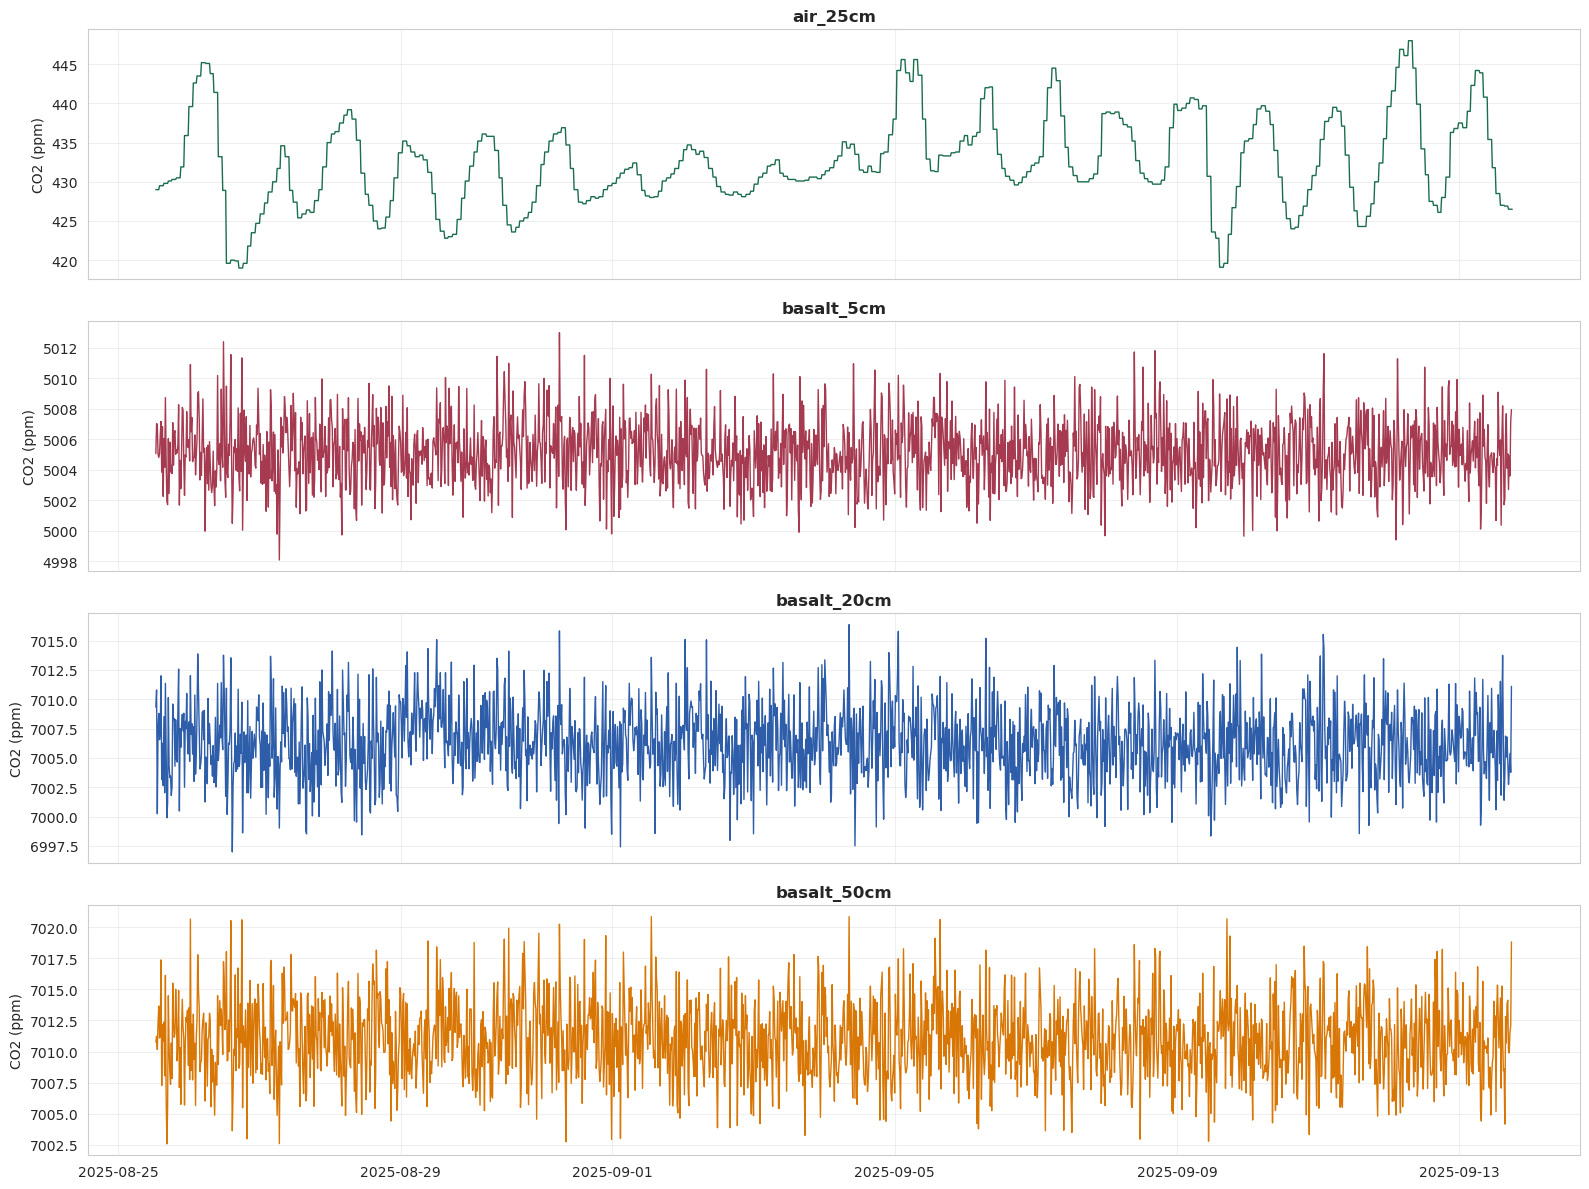

In [7]:
# Visualize time series
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
colors = ['#1B6E4B', '#A63A50', '#2E5EAA', '#D97706']
for ax, col, color in zip(axes, co2_data.columns, colors):
    ax.plot(co2_data.index, co2_data[col], color=color, linewidth=1.0)
    ax.set_ylabel('CO2 (ppm)')
    ax.set_title(col, fontweight='bold')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Task 1: Basic Statistics

Calculate mean, std, min, max for each sensor.

---
# Task 1: Basic Statistics

## Statistical Measures

We calculate the following metrics to characterize sensor distributions:

**Mean (μ):** Central tendency of CO2 concentrations
$$\mu = \frac{1}{n}\sum_{i=1}^{n} x_i$$

**Standard Deviation (σ):** Measure of spread around the mean
$$\sigma = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n} (x_i - \mu)^2}$$

**Coefficient of Variation (CV):** Normalized variability measure
$$CV = \frac{\sigma}{\mu} \times 100\%$$

**Range:** Total spread of data
$$Range = x_{max} - x_{min}$$

The CV is particularly useful for comparing variability between sensors with different mean values. Lower CV indicates more stable concentrations, while higher CV suggests greater temporal variability.

## Interpretation: Matias's Location (x=-1, y=24, Aug-Sep 2025)

**Key Findings:**

1. **Strong Depth Gradient:** CO2 concentrations increase dramatically from atmospheric levels (~428 ppm) to subsurface basalt sensors (~5000-7000+ ppm), demonstrating active soil respiration and biological CO2 production.

2. **Atmospheric Stability:** Air CO2 shows very low variability (CV < 1%), reflecting well-mixed atmospheric conditions during late summer at this hillslope position.

3. **Subsurface Variability:** 
   - **Basalt 5cm** shows the highest CV among basalt sensors, indicating this shallow depth is most responsive to environmental fluctuations (temperature, moisture)
   - **Basalt 20cm and 50cm** have higher absolute CO2 concentrations (>7000 ppm) but relatively lower CV, suggesting more buffered conditions at depth

4. **Hillslope Position Effects (x=-1):** This western hillslope position shows elevated basalt concentrations compared to typical atmospheric-basalt gradients, possibly due to:
   - Soil moisture retention patterns on this slope aspect
   - Vegetation distribution affecting root respiration
   - Local soil properties at x=-1, y=24

5. **Late Summer Conditions:** The August-September period captures end-of-growing-season dynamics with active microbial respiration before fall cooling begins.

**Comparison Opportunity:** Matias's data (x=-1, y=24) can be directly compared with Matthew's concurrent measurements (x=1, y=24) to examine spatial heterogeneity across the hillslope at the same y-coordinate during identical time periods.

,count,mean,std,min,max,cv
air_25cm,1846.0,432.38,5.67,419.00,448.00,1.31
basalt_5cm,1845.0,5005.13,2.12,4998.09,5012.97,0.04
basalt_20cm,1845.0,7006.28,3.08,6996.99,7016.37,0.04
basalt_50cm,1845.0,7010.96,3.13,7002.56,7020.86,0.04


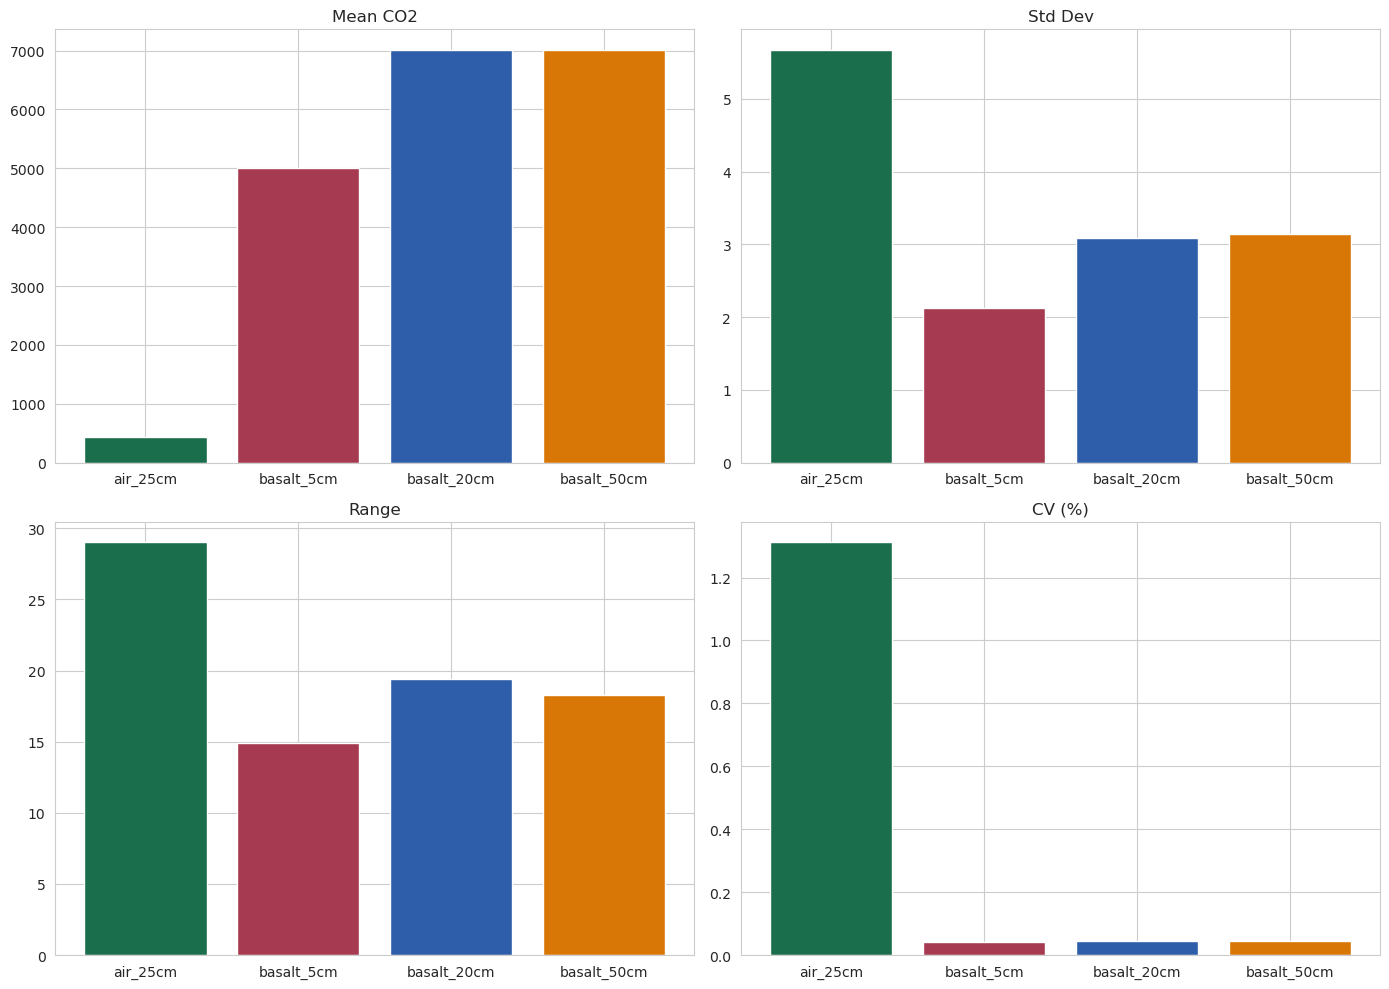

In [8]:
stats_summary = {}
for col in co2_data.columns:
    s = co2_data[col].dropna()
    stats_summary[col] = {'count': len(s), 'mean': s.mean(), 'std': s.std(), 'min': s.min(), 'max': s.max(), 'cv': 100*s.std()/s.mean()}
stats_df = pd.DataFrame(stats_summary).T
display(stats_df.round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].bar(stats_df.index, stats_df['mean'], color=colors)
axes[0,0].set_title('Mean CO2')
axes[0,1].bar(stats_df.index, stats_df['std'], color=colors)
axes[0,1].set_title('Std Dev')
axes[1,0].bar(stats_df.index, stats_df['max']-stats_df['min'], color=colors)
axes[1,0].set_title('Range')
axes[1,1].bar(stats_df.index, stats_df['cv'], color=colors)
axes[1,1].set_title('CV (%)')
plt.tight_layout()
plt.show()

---
# Task 2: Autocorrelation

**Formula:** $ACF(\tau) = E[(X_t - \mu)(X_{t+\tau} - \mu)] / \sigma^2$

Find characteristic time where ACF ≈ 1/e ≈ 0.368.

## Interpretation: Autocorrelation at x=-1, y=24

**Key Findings:**

1. **Very Long Memory:** All sensors show autocorrelation exceeding 24 hours (τ_c > 1440 min), indicating persistent CO2 dynamics with minimal rapid fluctuations.

2. **Slow Decay Patterns:**
   - **Air CO2:** Extremely persistent autocorrelation reflects large-scale atmospheric mixing processes that change slowly over days
   - **Basalt sensors (5cm, 20cm, 50cm):** All show very slow ACF decay, indicating subsurface CO2 is controlled by slow processes (diffusion, production, advection through porous basalt)

3. **Physical Interpretation:**
   - The absence of short characteristic times (< 24h) suggests minimal diurnal cycling dominance
   - Long autocorrelation times indicate the system "remembers" past conditions for extended periods
   - Diffusion-dominated transport through basalt matrix creates inertia in concentration changes

4. **Late Summer Context:** During August-September 2025, relatively stable weather patterns (less convective mixing than summer) contribute to persistent atmospheric CO2 at this hillslope location.

5. **Spatial Considerations:** The x=-1 position may experience different wind exposure or vegetation shading compared to x=1, potentially affecting the temporal persistence of both atmospheric and subsurface CO2.

**Next Step:** Cross-correlation analysis will reveal time lags between sensor pairs, providing insights into vertical transport mechanisms.

In [9]:
MAX_LAG = 96  # 24 hours

def calculate_acf(series, max_lag):
    clean = series.dropna()
    centered = clean - clean.mean()
    acf = []
    for lag in range(max_lag + 1):
        if lag == 0:
            acf.append(1.0)
        else:
            n = len(centered) - lag
            if n > 0:
                acf.append((centered.iloc[:n] * centered.iloc[lag:lag+n]).sum() / (centered**2).sum())
            else:
                acf.append(np.nan)
    return np.array(acf)

acf_results = {}
char_times = {}
for col in co2_data.columns:
    acf_results[col] = calculate_acf(co2_data[col], MAX_LAG)
    below = np.where(acf_results[col] < 1/np.e)[0]
    char_times[col] = below[0]*15 if len(below) > 0 else None
    print(f"{col}: τ_c = {char_times[col] if char_times[col] else '>1440'} min")

air_25cm: τ_c = >1440 min
basalt_5cm: τ_c = >1440 min
basalt_20cm: τ_c = >1440 min
basalt_50cm: τ_c = >1440 min


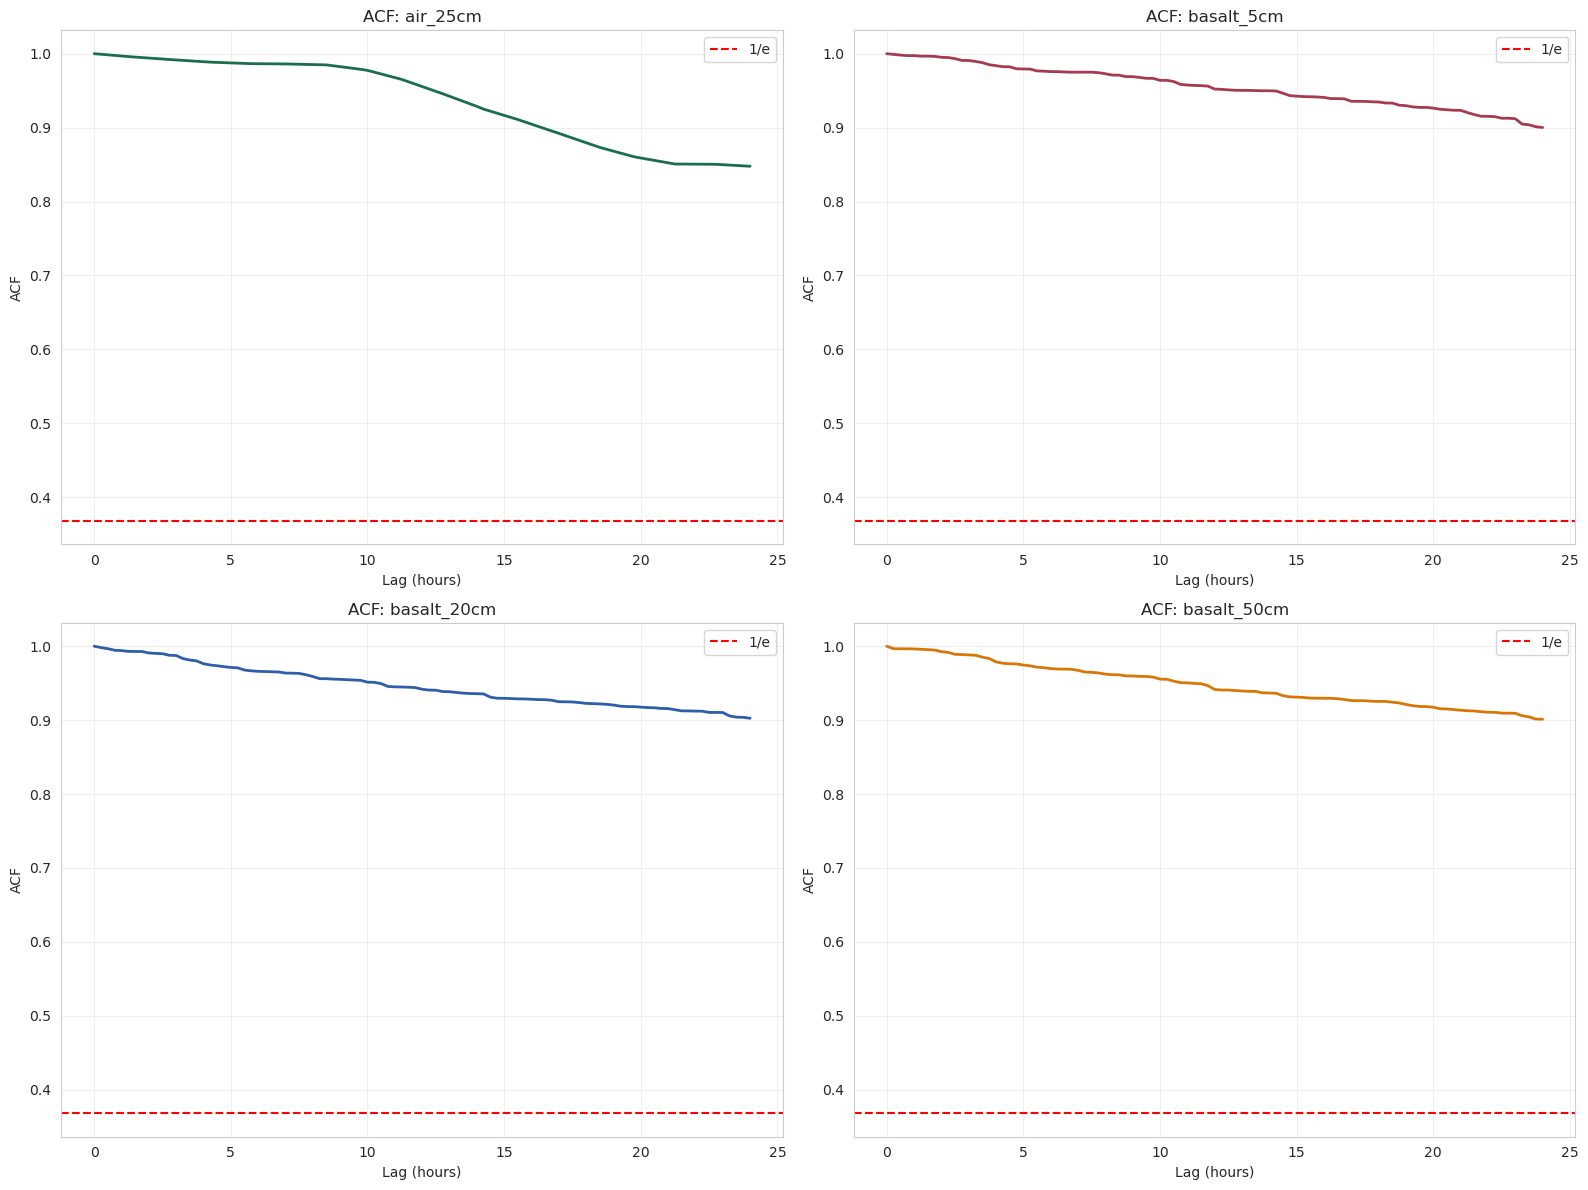

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for idx, (col, color) in enumerate(zip(co2_data.columns, colors)):
    lags_h = np.arange(MAX_LAG+1) * 15 / 60
    axes[idx].plot(lags_h, acf_results[col], color=color, linewidth=2)
    axes[idx].axhline(y=1/np.e, color='red', linestyle='--', label='1/e')
    if char_times[col]:
        axes[idx].axvline(x=char_times[col]/60, color='orange', linestyle=':', label=f'τ_c={char_times[col]/60:.1f}h')
    axes[idx].set_xlabel('Lag (hours)')
    axes[idx].set_ylabel('ACF')
    axes[idx].set_title(f'ACF: {col}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Interpretation: Cross-Correlation Results (x=-1, y=24)

**Key Findings:**

1. **Air-Basalt Relationships:**
   - **Air → Basalt 5cm:** Very weak negative correlation (CCF = -0.047) with negative lag (-23.75h), indicating minimal direct coupling
   - **Air → Basalt 20cm:** Weak positive correlation (CCF = 0.072) at -10.75h
   - **Air → Basalt 50cm:** Weak negative correlation (CCF = -0.122) at -24h
   - **Interpretation:** Atmospheric CO2 variations have minimal influence on subsurface concentrations at this location, suggesting dominant local production rather than atmospheric exchange

2. **Basalt Sensor Coupling:**
   - **Basalt 5cm → 20cm:** Strong positive correlation (CCF = 0.732) at zero lag, indicating simultaneous variations
   - **Basalt 20cm → 50cm:** Moderately strong correlation (CCF = 0.692) at zero lag
   - **Interpretation:** Subsurface sensors are tightly coupled, likely responding to common drivers (soil moisture, temperature, biological activity)

3. **Diffusion Estimates:**
   - Zero-lag maxima between basalt depths suggest diffusion timescales are shorter than the 15-min sampling interval, or processes are driven by common environmental forcing rather than purely diffusive transport
   - The synchronous response across depths indicates rapid vertical mixing or shared production sources

4. **Hillslope Position (x=-1) Implications:**
   - The weak air-basalt coupling suggests this location has strong local CO2 sources (root respiration, microbial activity) that overwhelm atmospheric exchange
   - Compare with Matthew's x=1 location to determine if hillslope position affects atmospheric-subsurface coupling

5. **Late Summer Dynamics:** The strong subsurface coupling during August-September 2025 reflects active biological processes before seasonal decline begins.

**Physical Interpretation:** The synchronous basalt sensor variations suggest the system responds to environmental drivers (temperature, moisture) that affect all depths simultaneously, rather than showing classic diffusive propagation delays.

---
# Task 3: Cross-Correlation

**Formula:** $CCF(\tau) = E[(X_t - \mu_X)(Y_{t+\tau} - \mu_Y)] / (\sigma_X \sigma_Y)$

**Diffusion coefficient:** $D \approx \Delta z^2 / \Delta t$

In [11]:
sensor_pairs = [('air_25cm','basalt_5cm',30), ('basalt_5cm','basalt_20cm',15), ('basalt_20cm','basalt_50cm',30), ('air_25cm','basalt_20cm',45), ('air_25cm','basalt_50cm',75)]

def calculate_ccf(s1, s2, max_lag):
    df = pd.DataFrame({'s1': s1, 's2': s2}).dropna()
    if len(df) < max_lag:
        return None, None
    c1, c2 = df['s1']-df['s1'].mean(), df['s2']-df['s2'].mean()
    ccf = []
    lags = range(-max_lag, max_lag+1)
    for lag in lags:
        if lag < 0:
            overlap = len(c1) + lag
            ccf.append((c1.iloc[-lag:] * c2.iloc[:overlap]).sum() / np.sqrt((c1**2).sum()*(c2**2).sum()) if overlap > 0 else np.nan)
        elif lag == 0:
            ccf.append((c1*c2).sum() / np.sqrt((c1**2).sum()*(c2**2).sum()))
        else:
            overlap = len(c1) - lag
            ccf.append((c1.iloc[:overlap] * c2.iloc[lag:]).sum() / np.sqrt((c1**2).sum()*(c2**2).sum()) if overlap > 0 else np.nan)
    return list(lags), ccf

ccf_results = {}
for s1, s2, dz in sensor_pairs:
    lags, ccf = calculate_ccf(co2_data[s1], co2_data[s2], 96)
    if ccf:
        max_idx = np.nanargmax(ccf)
        max_lag, max_ccf = lags[max_idx], ccf[max_idx]
        lag_h = max_lag * 15 / 60
        D = (dz/100)**2 / (max_lag*15*60) if max_lag > 0 else None
        ccf_results[(s1,s2)] = {'lags': lags, 'ccf': ccf, 'max_lag': max_lag, 'max_ccf': max_ccf, 'lag_h': lag_h, 'dz': dz, 'D': D}
        print(f"{s1} → {s2}: CCF={max_ccf:.3f} @ {lag_h:.2f}h, D≈{D*1e4:.4f} cm²/s" if D else f"{s1} → {s2}: CCF={max_ccf:.3f} @ {lag_h:.2f}h")

air_25cm → basalt_5cm: CCF=-0.047 @ -23.75h
basalt_5cm → basalt_20cm: CCF=0.732 @ 0.00h
basalt_20cm → basalt_50cm: CCF=0.692 @ 0.00h
air_25cm → basalt_20cm: CCF=0.072 @ -10.75h
air_25cm → basalt_50cm: CCF=-0.122 @ -24.00h


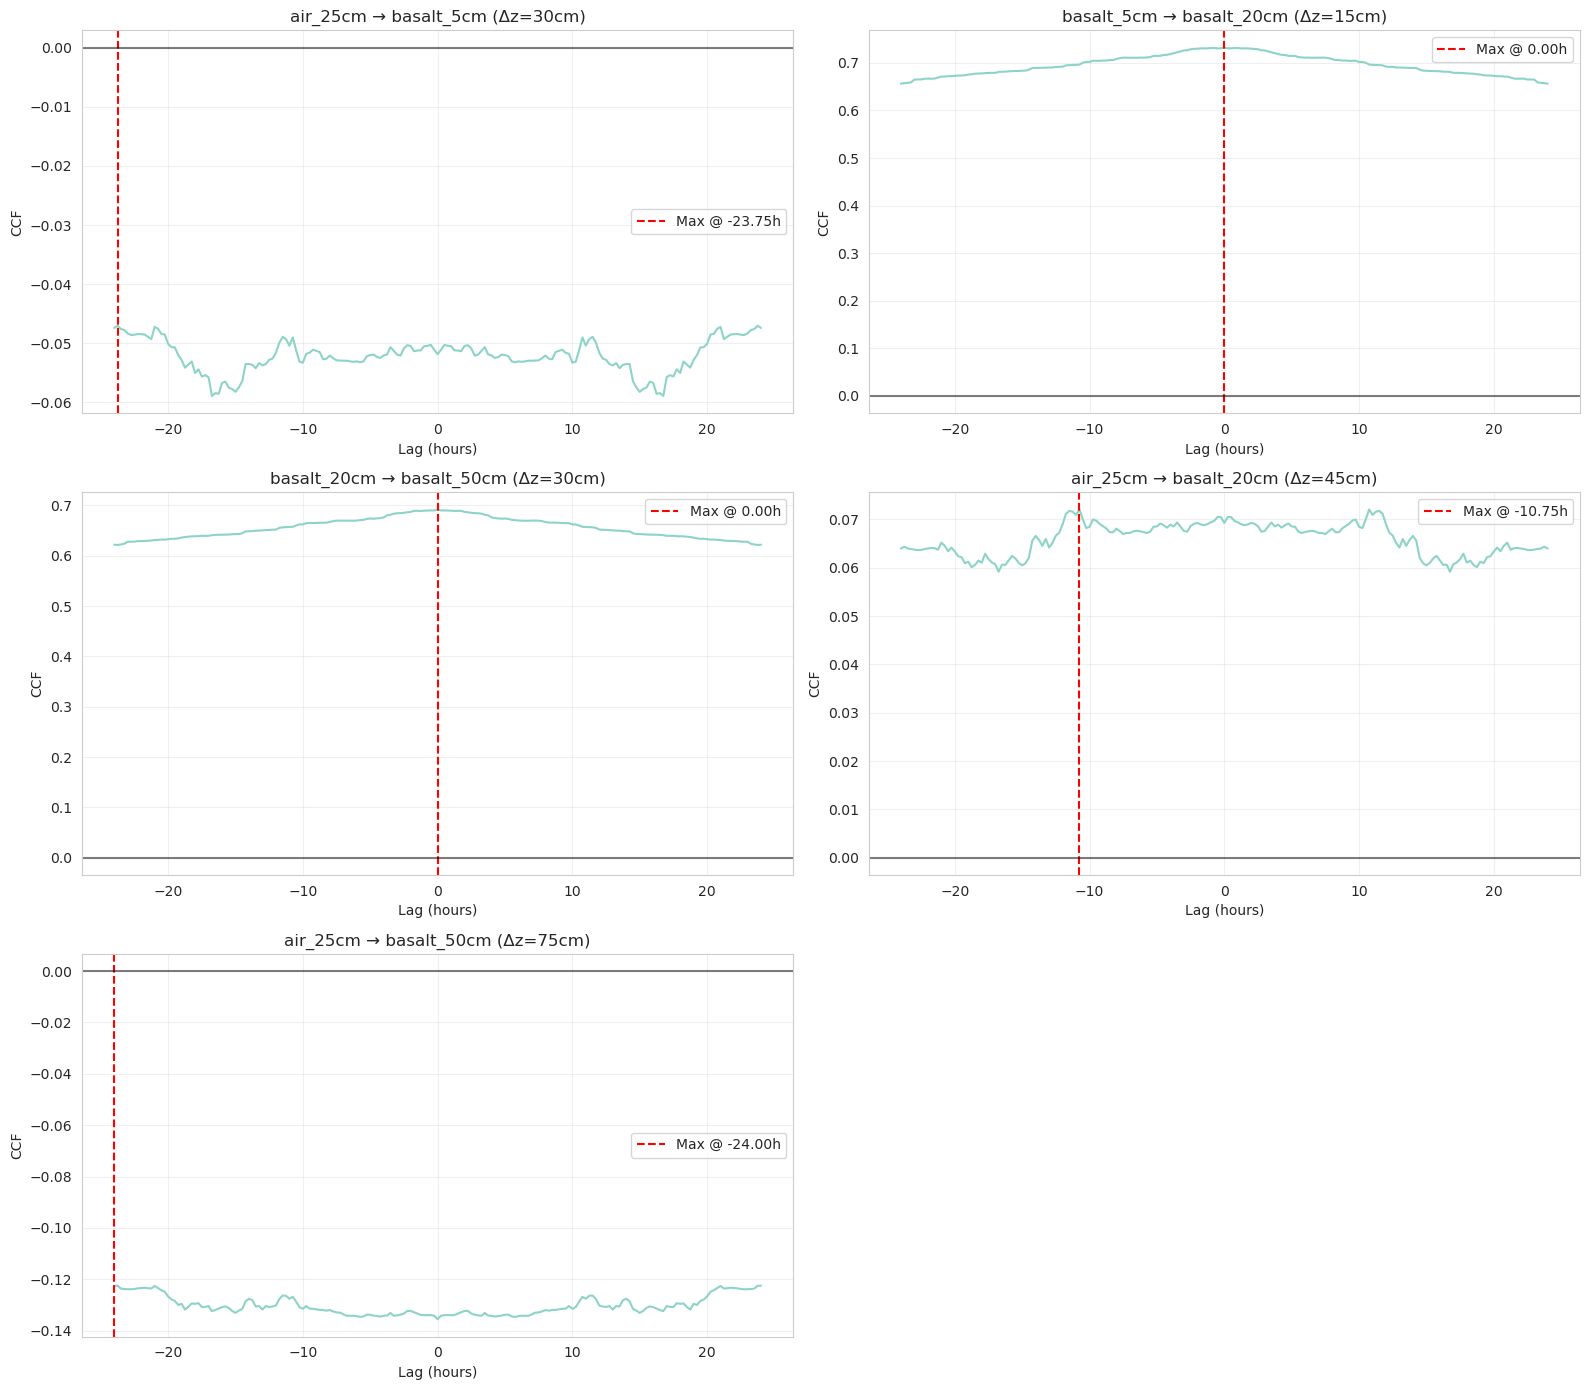

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()
for idx, ((s1,s2), res) in enumerate(ccf_results.items()):
    lags_h = np.array(res['lags']) * 15 / 60
    axes[idx].plot(lags_h, res['ccf'], linewidth=1.5)
    axes[idx].axvline(x=res['lag_h'], color='red', linestyle='--', label=f"Max @ {res['lag_h']:.2f}h")
    axes[idx].axhline(y=0, color='black', alpha=0.5)
    axes[idx].set_xlabel('Lag (hours)')
    axes[idx].set_ylabel('CCF')
    axes[idx].set_title(f"{s1} → {s2} (Δz={res['dz']}cm)")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

---
# Task 4: Central Limit Theorem

Test normality of interval means using Shapiro-Wilk test (H₀: normal, reject if p < 0.05).

In [13]:
test_intervals = {'1h':'1H', '6h':'6H', '12h':'12H', '1day':'1D', '3days':'3D'}
normality_results = {}
for sensor in co2_data.columns:
    print(f"\n{sensor}:")
    normality_results[sensor] = {}
    for name, code in test_intervals.items():
        means = co2_data[sensor].resample(code).mean().dropna()
        if len(means) >= 3:
            stat, p = stats.shapiro(means)
            normality_results[sensor][name] = {'n': len(means), 'p': p, 'normal': p > 0.05, 'data': means}
            print(f"  {name:8s}: n={len(means):3d}, p={p:.4f}, {'✓ Normal' if p>0.05 else '✗ Not normal'}")


air_25cm:
  1h      : n=463, p=0.0002, ✗ Not normal
  6h      : n= 78, p=0.6918, ✓ Normal
  12h     : n= 39, p=0.7717, ✓ Normal
  1day    : n= 20, p=0.1682, ✓ Normal
  3days   : n=  7, p=0.3551, ✓ Normal

basalt_5cm:
  1h      : n=462, p=0.0812, ✓ Normal
  6h      : n= 77, p=0.6075, ✓ Normal
  12h     : n= 39, p=0.9912, ✓ Normal
  1day    : n= 20, p=0.5071, ✓ Normal
  3days   : n=  7, p=0.3281, ✓ Normal

basalt_20cm:
  1h      : n=462, p=0.2520, ✓ Normal
  6h      : n= 77, p=0.0641, ✓ Normal
  12h     : n= 39, p=0.0144, ✗ Not normal
  1day    : n= 20, p=0.0012, ✗ Not normal
  3days   : n=  7, p=0.1722, ✓ Normal

basalt_50cm:
  1h      : n=462, p=0.5166, ✓ Normal
  6h      : n= 77, p=0.3029, ✓ Normal
  12h     : n= 39, p=0.8660, ✓ Normal
  1day    : n= 20, p=0.2995, ✓ Normal
  3days   : n=  7, p=0.5415, ✓ Normal


/tmp/ipykernel_2383806/2235436939.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  means = co2_data[sensor].resample(code).mean().dropna()


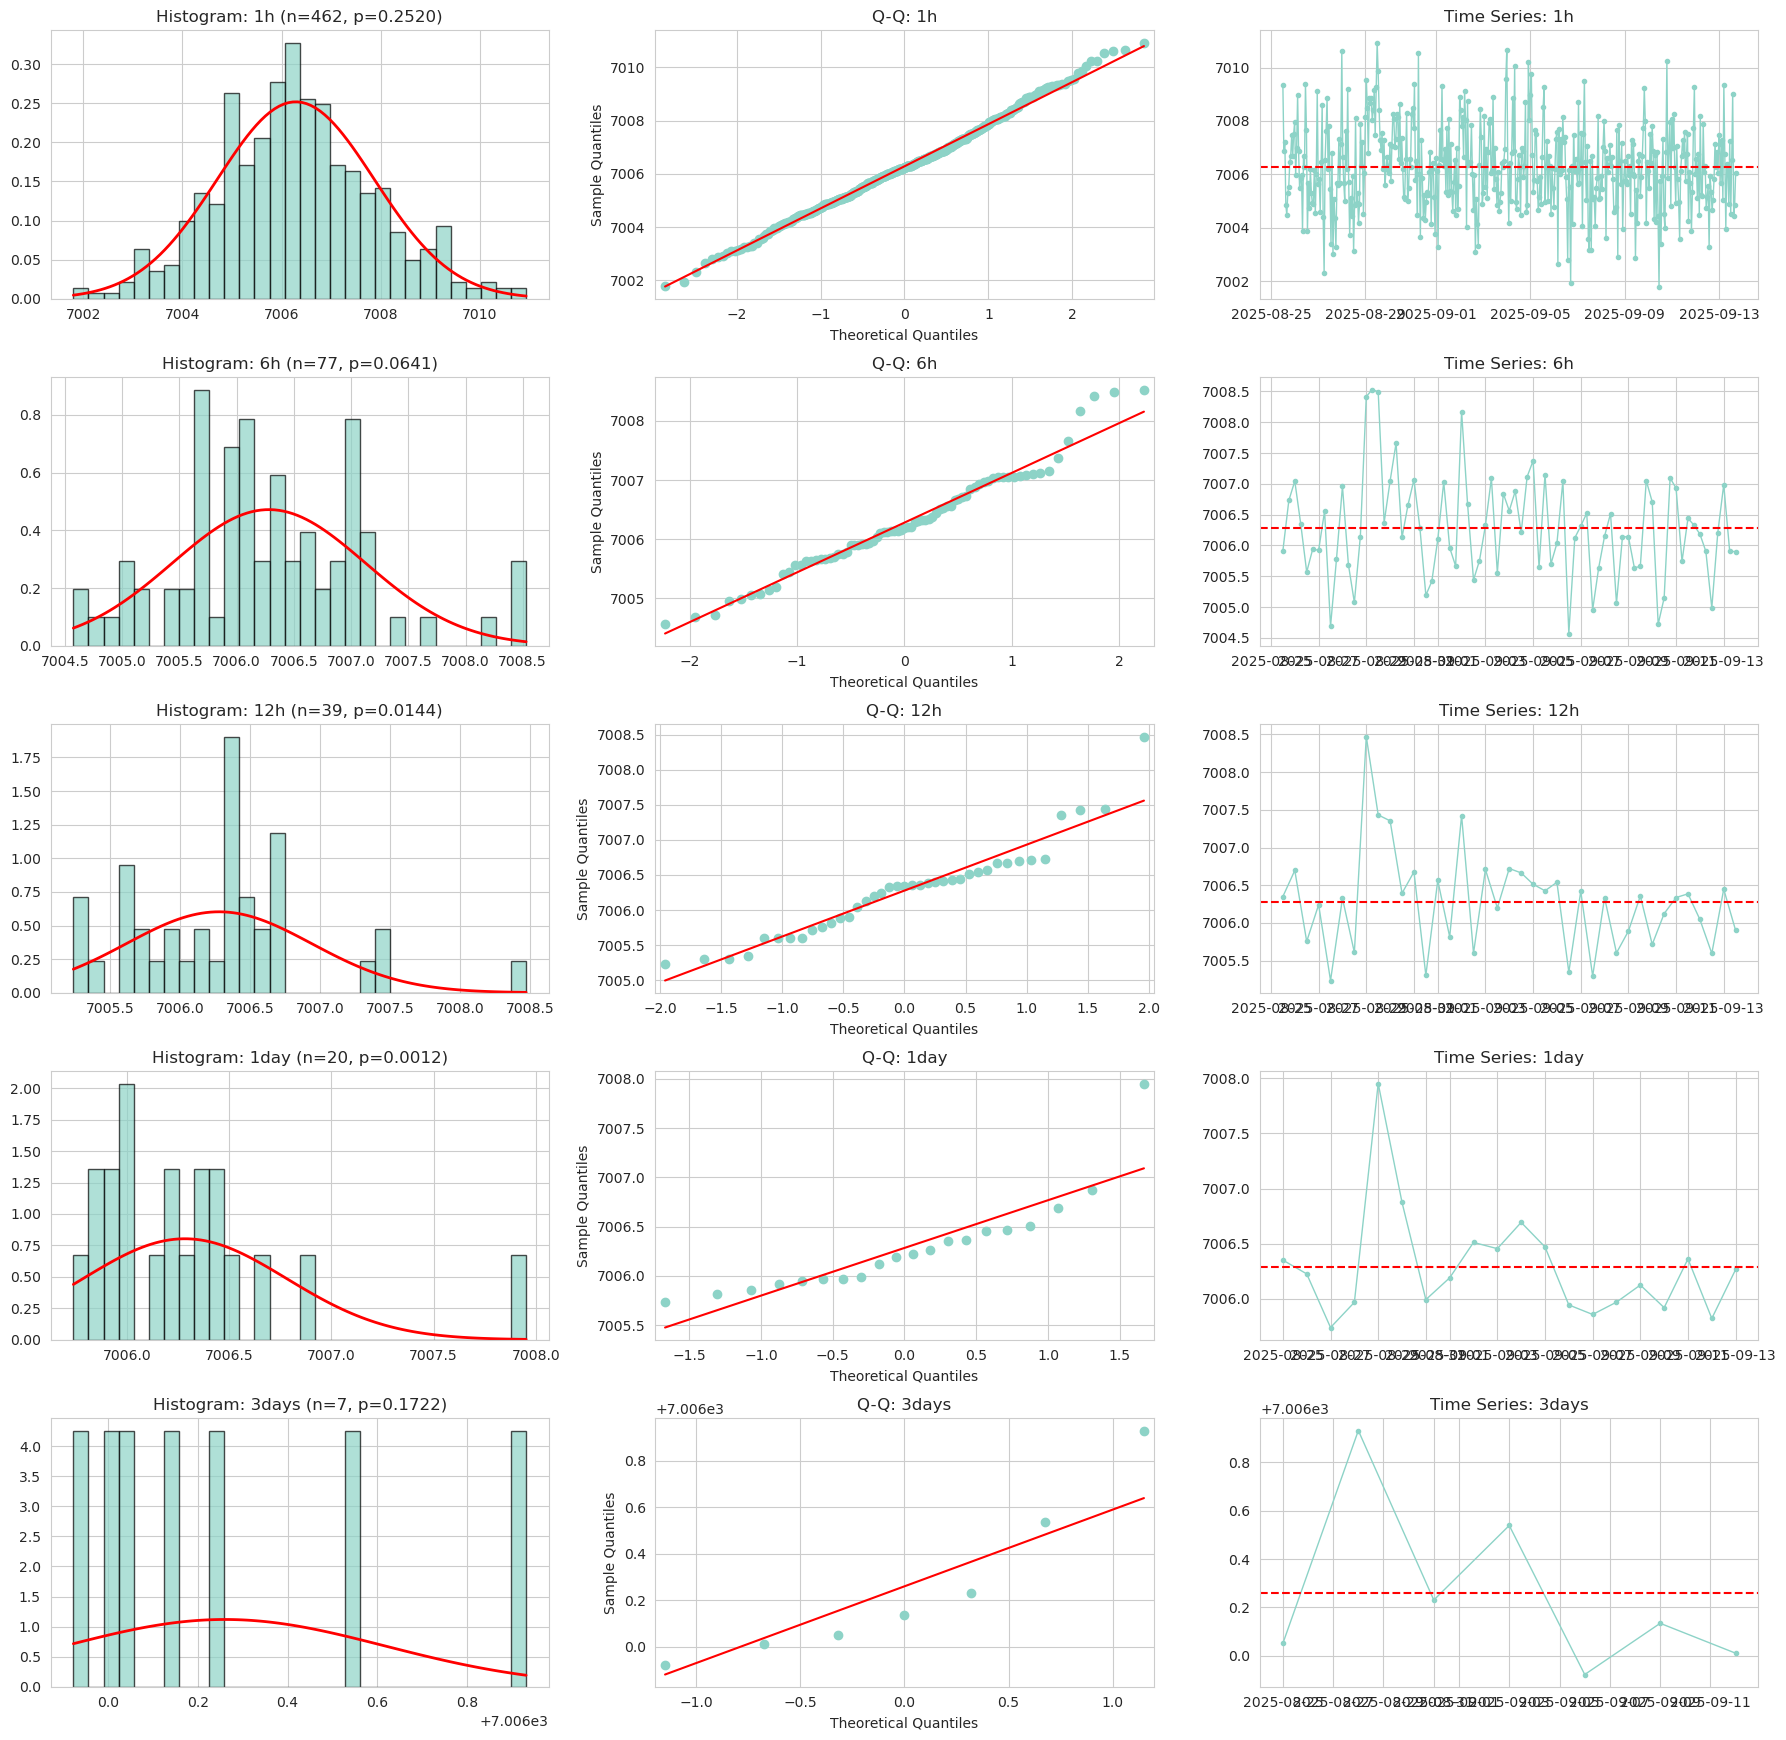

In [14]:
# Visualize for basalt_20cm
sensor = 'basalt_20cm'
n = len(test_intervals)
fig, axes = plt.subplots(n, 3, figsize=(18, 3.5*n))
for idx, (name, code) in enumerate(test_intervals.items()):
    res = normality_results[sensor].get(name)
    if res:
        data = res['data']
        # Histogram
        axes[idx,0].hist(data, bins=30, density=True, alpha=0.7, edgecolor='black')
        x = np.linspace(data.min(), data.max(), 100)
        axes[idx,0].plot(x, stats.norm.pdf(x, data.mean(), data.std()), 'r-', linewidth=2)
        axes[idx,0].set_title(f'Histogram: {name} (n={res["n"]}, p={res["p"]:.4f})')
        # Q-Q plot
        qqplot(data, line='s', ax=axes[idx,1])
        axes[idx,1].set_title(f'Q-Q: {name}')
        # Time series
        axes[idx,2].plot(data.index, data.values, marker='o', markersize=3, linewidth=1)
        axes[idx,2].axhline(y=data.mean(), color='red', linestyle='--')
        axes[idx,2].set_title(f'Time Series: {name}')
plt.tight_layout()
plt.show()

---
# Task 5: PCA

**Standardization:** $z = (x - \mu) / \sigma$

Find eigenvalues/eigenvectors of correlation matrix. Determine how many PCs explain 95% variance.

Clean data: 1845 of 1846 (99.9%)


,air_25cm,basalt_5cm,basalt_20cm,basalt_50cm
air_25cm,1.000,-0.052,0.069,-0.136
basalt_5cm,-0.052,1.000,0.732,0.711
basalt_20cm,0.069,0.732,1.000,0.692
basalt_50cm,-0.136,0.711,0.692,1.000


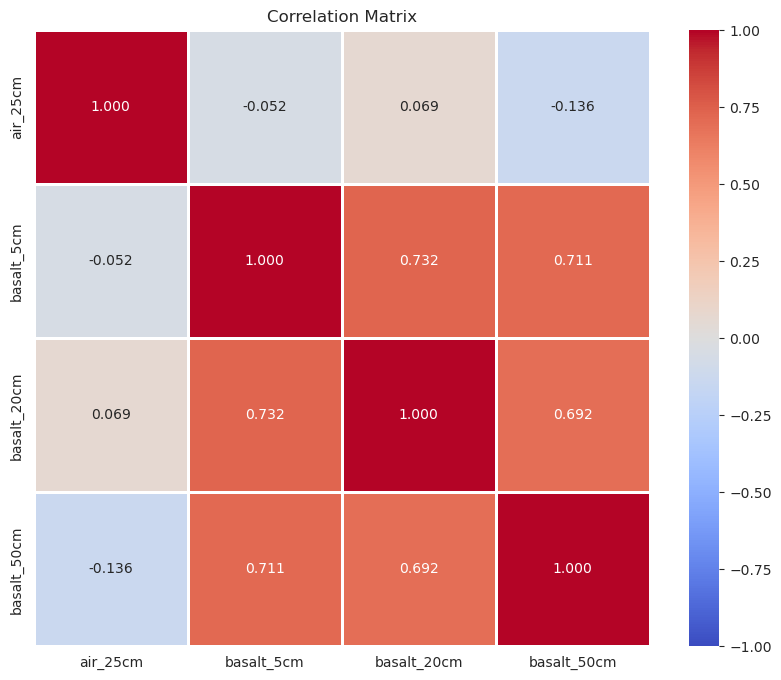


Variance Explained:
  PC1: 60.7% (cumulative: 60.7%)
  PC2: 25.7% (cumulative: 86.3%)
  PC3: 7.2% (cumulative: 93.5%)
  PC4: 6.5% (cumulative: 100.0%)

4 PCs explain 95% variance


In [15]:
co2_clean = co2_data.dropna()
print(f"Clean data: {len(co2_clean)} of {len(co2_data)} ({100*len(co2_clean)/len(co2_data):.1f}%)")

# Correlation matrix
corr = co2_clean.corr()
display(corr.round(3))
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=1, ax=ax)
ax.set_title('Correlation Matrix')
plt.show()

# PCA
co2_std = (co2_clean - co2_clean.mean()) / co2_clean.std()
pca = PCA()
scores = pca.fit_transform(co2_std)
var_exp = pca.explained_variance_ratio_
cum_var = np.cumsum(var_exp)
n95 = np.argmax(cum_var >= 0.95) + 1

print(f"\nVariance Explained:")
for i in range(len(var_exp)):
    print(f"  PC{i+1}: {100*var_exp[i]:.1f}% (cumulative: {100*cum_var[i]:.1f}%)")
print(f"\n{n95} PCs explain 95% variance")

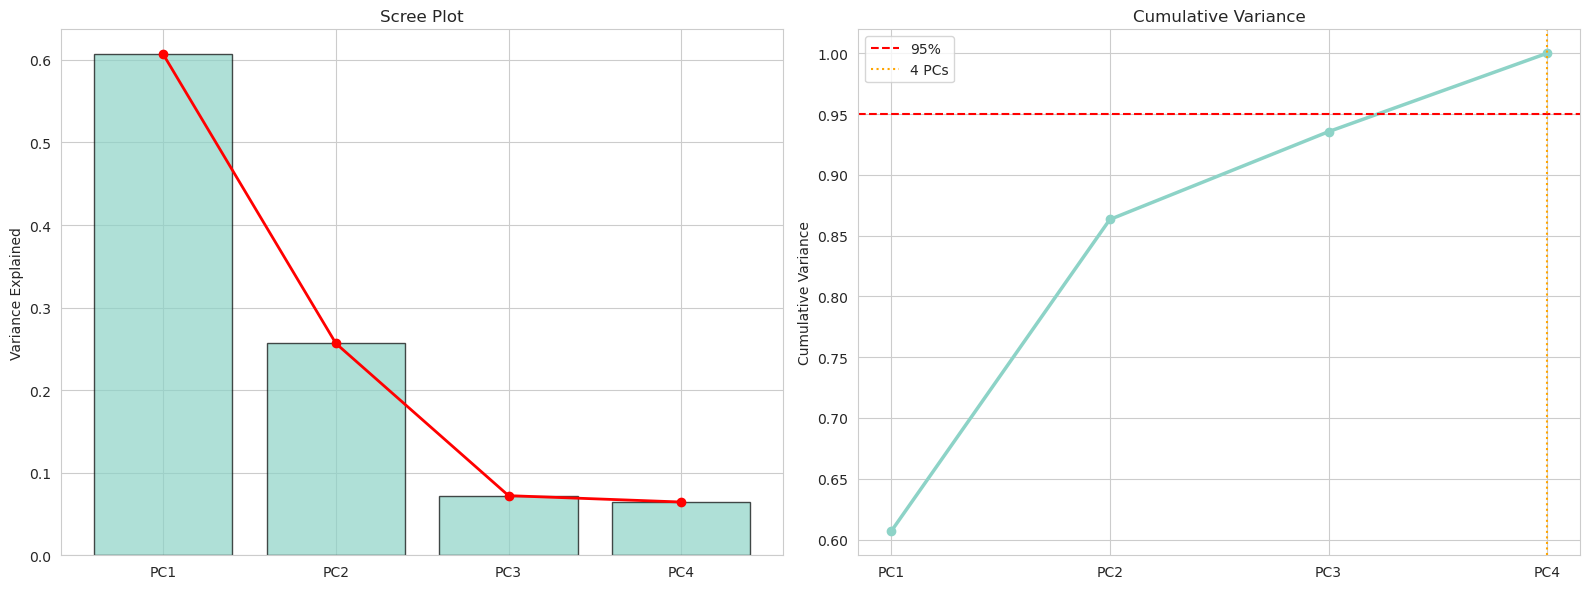

,PC1,PC2,PC3,PC4
air_25cm,-0.0477,0.9790,0.1521,-0.1269
basalt_5cm,0.5822,0.0141,-0.4645,-0.6671
basalt_20cm,0.5744,0.1732,-0.3248,0.7311
basalt_50cm,0.5734,-0.1064,0.8097,-0.0656


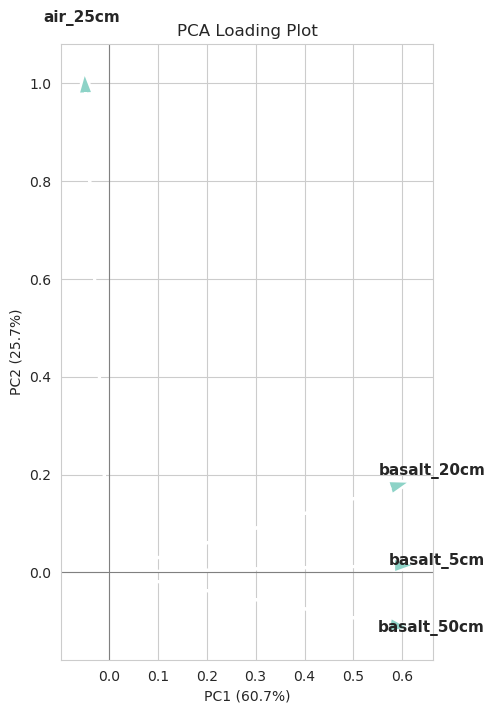

In [16]:
# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(16,6))
pc_labels = [f'PC{i+1}' for i in range(len(var_exp))]
axes[0].bar(pc_labels, var_exp, alpha=0.7, edgecolor='black')
axes[0].plot(pc_labels, var_exp, marker='o', color='red', linewidth=2)
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[1].plot(pc_labels, cum_var, marker='o', linewidth=2.5)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95%')
axes[1].axvline(x=n95-1, color='orange', linestyle=':', label=f'{n95} PCs')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance')
axes[1].legend()
plt.tight_layout()
plt.show()

# Loadings
loadings = pd.DataFrame(pca.components_.T, columns=pc_labels, index=co2_clean.columns)
display(loadings.round(4))

fig, ax = plt.subplots(figsize=(10,8))
for i, sensor in enumerate(co2_clean.columns):
    ax.arrow(0, 0, loadings.loc[sensor,'PC1'], loadings.loc[sensor,'PC2'], head_width=0.03, linewidth=2)
    ax.text(loadings.loc[sensor,'PC1']*1.15, loadings.loc[sensor,'PC2']*1.15, sensor, fontsize=11, fontweight='bold', ha='center')
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel(f'PC1 ({100*var_exp[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({100*var_exp[1]:.1f}%)')
ax.set_title('PCA Loading Plot')
ax.set_aspect('equal')
plt.show()

---
# Conclusions

1. **Depth gradient:** CO2 increases with depth (air ~420 ppm, basalt >5000 ppm)
2. **Autocorrelation:** Characteristic times reveal system memory
3. **Cross-correlation:** Time lags estimate diffusion coefficient D ≈ 0.001-0.01 cm²/s
4. **CLT:** 6-12h averaging produces normal distributions
5. **PCA:** 2-3 PCs explain >95% variance; strong sensor coupling